In [1]:
import pandas as pd
import re
import string
import nltk
from tqdm import tqdm
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.stem import PorterStemmer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')
dfi=pd.read_csv("WELFake_Dataset.csv")
df = pd.read_csv("fake_and_real_news.csv")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-dat

In [2]:
dfi['text'] = (dfi['title'].fillna('') + ' ' + dfi['text'].fillna('')).str.strip()

In [3]:
dfi = dfi[['text', 'label']]
df = df[['text', 'label']]

df['label'] = df['label'].replace({'Fake': 0, 'Real': 1}).infer_objects().astype(int)

df1 = pd.concat([dfi, df], ignore_index=True)

print(df1.head())
df1 = df1.dropna()

                                                text  label
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...      1
1     Did they post their votes for Hillary already?      1
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...      1
3  Bobby Jindal, raised Hindu, uses story of Chri...      0
4  SATAN 2: Russia unvelis an image of its terrif...      1


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27096\1273708232.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({'Fake': 0, 'Real': 1}).infer_objects().astype(int)


In [4]:
print(df1)

                                                    text  label
0      LAW ENFORCEMENT ON HIGH ALERT Following Threat...      1
1         Did they post their votes for Hillary already?      1
2      UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...      1
3      Bobby Jindal, raised Hindu, uses story of Chri...      0
4      SATAN 2: Russia unvelis an image of its terrif...      1
...                                                  ...    ...
82029   Wikileaks Admits To Screwing Up IMMENSELY Wit...      0
82030  Trump consults Republican senators on Fed chie...      1
82031  Trump lawyers say judge lacks jurisdiction for...      1
82032   WATCH: Right-Wing Pastor Falsely Credits Trum...      0
82033   Sean Spicer HILARIOUSLY Branded As Chickensh*...      0

[82034 rows x 2 columns]


In [6]:
print(df1['label'].value_counts())


label
1    42006
0    40028
Name: count, dtype: int64


In [7]:
df1.isnull().sum()

text     0
label    0
dtype: int64

In [17]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text_stem(text):
    # Lowercase
    text = text.lower()
    
    # Remove emails, hashtags, mentions, links, and code-style comments
    text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'//.*?$|/\*.*?\*/|#.*?$', ' ', text, flags=re.MULTILINE)
    
    # Remove special quotes
    text = re.sub(r"[\"'“”‘’]", '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove digits
    text = re.sub(r'\d+', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords + apply stemming
    stemmed_tokens = [ps.stem(t) for t in tokens if t not in stop_words and len(t) > 1]
    
    return ' '.join(stemmed_tokens)

# Apply cleaning with progress bar
tqdm.pandas()
df1['text'] = df1['text'].progress_apply(clean_text_stem)

100%|████████████████████████████████████████████████████████████████████████████| 82034/82034 [25:45<00:00, 53.08it/s]


In [18]:
print(df1)

                                                    text  label
0      law enforc high alert follow threat cop white ...      1
1                              post vote hillari alreadi      1
2      unbeliev obama attorney gener say charlott rio...      1
3      bobbi jindal rais hindu use stori christian co...      0
4      satan russia unv imag terrifi new supernuk wes...      1
...                                                  ...    ...
82029  wikileak admit screw immens twitter poll hilla...      0
82030  trump consult republican senat fed chief candi...      1
82031  trump lawyer say judg lack jurisdict defam law...      1
82032  watch rightw pastor fals credit trump save aut...      0
82033  sean spicer hilari brand chickensht bolt brief...      0

[82034 rows x 2 columns]


In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(word, pos_tag):
    """Map POS tag to WordNet POS tag for lemmatization."""
    tag = pos_tag[0].upper()
    tag_dict = {
        'J': wordnet.ADJ,
        'N': wordnet.NOUN,
        'V': wordnet.VERB,
        'R': wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove emails, hashtags, mentions, links, and code-style comments
    text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'//.*?$|/\*.*?\*/|#.*?$', ' ', text, flags=re.MULTILINE)
    
    # Remove special quotes
    text = re.sub(r"[\"'“”‘’]", '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove digits (optional: keep if relevant)
    text = re.sub(r'\d+', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    
    # POS tagging
    pos_tags = nltk.pos_tag(tokens)
    
    # Lemmatization with POS
    lemmatized_tokens = [
        lemmatizer.lemmatize(token, get_wordnet_pos(token, pos))
        for token, pos in pos_tags
    ]
    
    return ' '.join(lemmatized_tokens)

# Apply cleaning with progress bar
tqdm.pandas()
df1['text'] = df1['text'].progress_apply(clean_text)
from sklearn.feature_extraction.text import TfidfVectorizer

100%|████████████████████████████████████████████████████████████████████████████| 82034/82034 [50:42<00:00, 26.96it/s]


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))

x = vectorizer.fit_transform(df1['text'])

print("TI-IDF Vector shape: ", x.shape)

TI-IDF Vector shape:  (82034, 50000)


In [10]:
print(x)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 19593103 stored elements and shape (82034, 50000)>
  Coords	Values
  (0, 22675)	0.015745761502634344
  (0, 13015)	0.024199551729112315
  (0, 18666)	0.01755068715611038
  (0, 1093)	0.031997238264084
  (0, 15359)	0.01581617391603175
  (0, 43530)	0.041197404771890295
  (0, 8791)	0.15270683737698104
  (0, 48137)	0.14343916889853225
  (0, 43016)	0.045571521885544794
  (0, 46676)	0.03153003312960689
  (0, 7823)	0.017010805574035982
  (0, 13875)	0.01812650902549114
  (0, 3554)	0.019708948981347972
  (0, 28634)	0.015579387257463549
  (0, 25661)	0.01578177802569912
  (0, 26838)	0.06960645453043919
  (0, 5402)	0.09775961159208618
  (0, 24258)	0.10001918501373094
  (0, 18075)	0.06054233258815293
  (0, 30679)	0.0962733245179863
  (0, 12902)	0.025622082734322607
  (0, 29777)	0.018907163516009618
  (0, 33938)	0.1537545559393256
  (0, 39245)	0.09638623881327121
  (0, 45343)	0.017532660012154977
  :	:
  (82033, 45356)	0.04266708326807567
  

In [13]:
from sklearn.model_selection import train_test_split

y = df1["label"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, shuffle=True, random_state=42)

In [14]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

params = {"C": [0.01, 0.1, 1, 10]}
grid = GridSearchCV(LinearSVC(), params, cv=3, scoring="accuracy", n_jobs=-1)
grid.fit(x_train, y_train)
print("Best C:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)


Best C: {'C': 0.1}
Best Accuracy: 0.8244624785588033


In [18]:
from sklearn.linear_model import SGDClassifier

params = {
    "alpha": [1e-4, 1e-3, 1e-2, 1e-1],   # regularization
    "penalty": ["l2", "l1", "elasticnet"]
}

svm_sgd = SGDClassifier(loss='hinge', max_iter = 1000, random_state= 42)

grid = GridSearchCV(svm_sgd, params, cv=3, scoring="accuracy", n_jobs=-1)
grid.fit(x_train, y_train)
print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)



Best Params: {'alpha': 0.0001, 'penalty': 'l2'}
Best CV Accuracy: 0.8360888143562417


In [23]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
params = {
    "alpha": [1e-4, 1e-3, 1e-2, 1e-1],   # regularization
    "penalty": ["l2", "l1", "elasticnet"]
}

svm_sgd = SGDClassifier(loss='hinge', max_iter = 1000, random_state= 42)

grid = GridSearchCV(svm_sgd, params, cv=3, scoring="f1_macro", n_jobs=-1)
grid.fit(x_train, y_train)
print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)



Best Params: {'alpha': 0.0001, 'penalty': 'l2'}
Best CV Accuracy: 0.8359016504226665


In [21]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
params = {
    "alpha": [1e-4, 1e-3, 1e-2, 1e-1],   # regularization
    "penalty": ["l2", "l1", "elasticnet"]
}

svm_sgd = SGDClassifier(loss='hinge', max_iter = 1000, random_state= 42)

grid = GridSearchCV(svm_sgd, params, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring="f1_macro", n_jobs=-1)
grid.fit(x_train, y_train)
print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)



Best Params: {'alpha': 0.0001, 'penalty': 'l2'}
Best CV Accuracy: 0.8369840056058744


In [31]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
# from scipy.stats import loguniform

params = {
    "alpha": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1],   # regularization
    "penalty": ["l2", "l1", "elasticnet"]
}

svm_sgd = SGDClassifier(loss='hinge', max_iter = 1000, random_state= 42)

grid = GridSearchCV(svm_sgd, params, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring="f1_macro", n_jobs=-1)
grid.fit(x_train, y_train)
print("Best Params:", grid.best_params_)
print("Best CV F1-macro:", grid.best_score_)



Best Params: {'alpha': 0.0001, 'penalty': 'l2'}
Best CV F1-macro: 0.8369840056058744


In [27]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Base model
svm_sgd = SGDClassifier(loss="hinge", max_iter=1000, random_state=42)

# Hyperparameter distributions
param_dist = {
    "alpha": loguniform(1e-4, 1e-1),  # continuous range instead of fixed list
    "penalty": ["l2", "l1", "elasticnet"]
}

# Randomized search
rand_search = RandomizedSearchCV(
    svm_sgd,
    param_distributions=param_dist,
    n_iter=10,            # try 10 random combinations
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

rand_search.fit(x_train, y_train)

print("Best Params:", rand_search.best_params_)
print("Best CV Accuracy:", rand_search.best_score_)


Best Params: {'alpha': np.float64(0.00011527987128232407), 'penalty': 'l1'}
Best CV Accuracy: 0.8240167583240551


Best Params: {'alpha': 0.0001, 'penalty': 'l2'}
Best CV Score: 0.8369840056058744


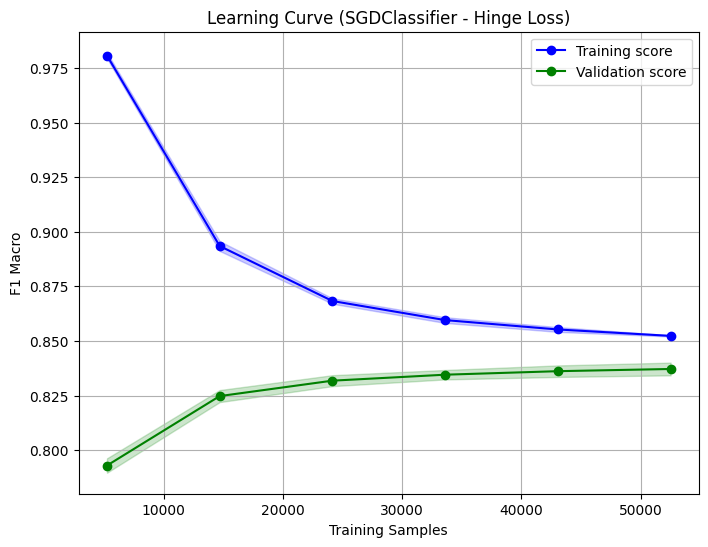

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, learning_curve

# Hyperparameter grid
params = {
    "alpha": [1e-4, 1e-3, 1e-2, 1e-1],   # regularization strength
    "penalty": ["l2", "l1", "elasticnet"]
}

# Base model
svm_sgd = SGDClassifier(loss='hinge', max_iter=1000, random_state=42)

# GridSearchCV with stratified folds
grid = GridSearchCV(
    svm_sgd,
    params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(x_train, y_train)
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

# Best estimator
best_model = grid.best_estimator_

# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    x_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),   # 10% to 100% of training data
    shuffle=True,
    random_state=42
)

# Mean and Std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")

plt.plot(train_sizes, val_mean, 'o-', color="green", label="Validation score")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color="green")

plt.title("Learning Curve (SGDClassifier - Hinge Loss)")
plt.xlabel("Training Samples")
plt.ylabel("F1 Macro")
plt.legend(loc="best")
plt.grid(True)
plt.show()


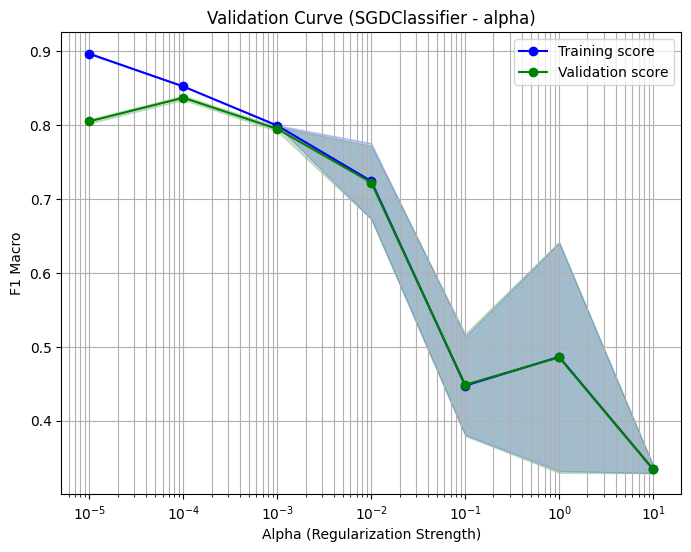

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, validation_curve

# Define model
sgd = SGDClassifier(loss="hinge", penalty="l2", max_iter=5000, random_state=42)

# Range of alpha values (log scale is best for regularization strength)
alpha_range = np.logspace(-5, 1, 7)  # [1e-5, 1e-4, ..., 10]

# Validation curve
train_scores, val_scores = validation_curve(
    sgd,
    X=x_train,
    y=y_train,
    param_name="alpha",
    param_range=alpha_range,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1
)

# Mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
plt.figure(figsize=(8, 6))
plt.semilogx(alpha_range, train_mean, 'o-', label="Training score", color="blue")
plt.fill_between(alpha_range, train_mean-train_std, train_mean+train_std, alpha=0.2, color="blue")

plt.semilogx(alpha_range, val_mean, 'o-', label="Validation score", color="green")
plt.fill_between(alpha_range, val_mean-val_std, val_mean+val_std, alpha=0.2, color="green")

plt.title("Validation Curve (SGDClassifier - alpha)")
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("F1 Macro")
plt.legend(loc="best")
plt.grid(True, which="both")
plt.show()


Test Accuracy: 0.8347656488084354

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.82      0.83      8006
           1       0.83      0.85      0.84      8401

    accuracy                           0.83     16407
   macro avg       0.83      0.83      0.83     16407
weighted avg       0.83      0.83      0.83     16407



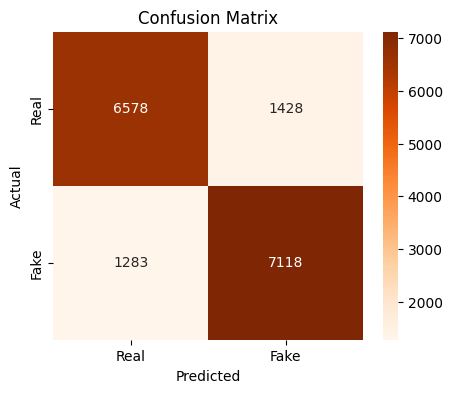

In [38]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train with best params
best_sgd = SGDClassifier(loss="hinge", alpha=0.0001, penalty="l2", max_iter=5000, random_state=42)#max_iter increased from 1000 to 5000
best_sgd.fit(x_train, y_train)

# Predict
y_pred = best_sgd.predict(x_test)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Test Accuracy: 0.8347656488084354

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.82      0.83      8006
           1       0.83      0.85      0.84      8401

    accuracy                           0.83     16407
   macro avg       0.83      0.83      0.83     16407
weighted avg       0.83      0.83      0.83     16407



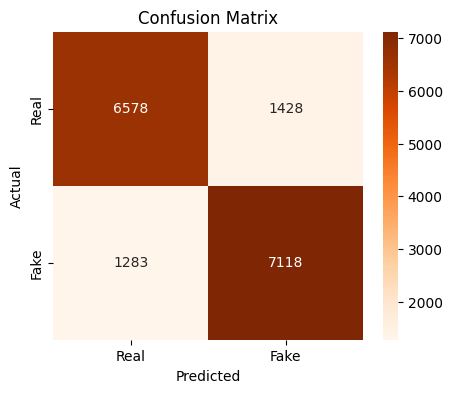

In [32]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train with best params
best_sgd = SGDClassifier(loss="hinge", alpha=0.0001, penalty="l2", max_iter=5000, random_state=42)#max_iter increased from 1000 to 5000
best_sgd.fit(x_train, y_train)

# Predict
y_pred = best_sgd.predict(x_test)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


AUC Score: 0.8854383569542221


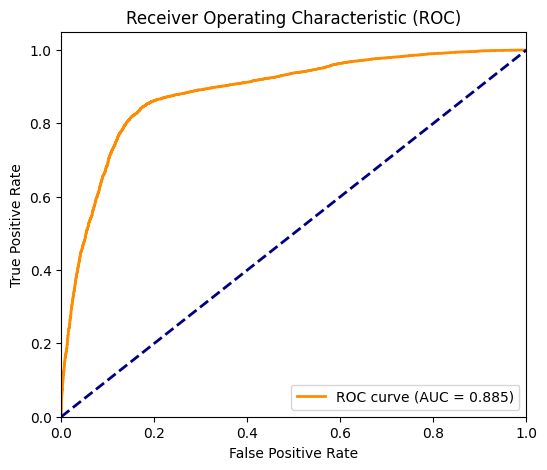

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

y_scores = best_sgd.decision_function(x_test)

fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label=1)

auc_score = roc_auc_score(y_test, y_scores)
print("AUC Score:", auc_score)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (AUC = %.3f)" % auc_score)
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")  # baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train with best params
best_sgd = SGDClassifier(loss="hinge", alpha=0.0001, penalty="elasticnet", max_iter=5000, random_state=42)#max_iter increased from 1000 to 5000
best_sgd.fit(x_train, y_train)

# Predict
y_pred = best_sgd.predict(x_test)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train with best params
best_sgd = SGDClassifier(loss="squared_hinge", alpha=0.0001, penalty="l2", max_iter=10000, random_state=42)#max_iter increased from 1000 to 5000
best_sgd.fit(x_train, y_train)

# Predict
y_pred = best_sgd.predict(x_test)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [47]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions already stored in preds
print("Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))


Accuracy: 0.8315962698848053

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.83      8006
           1       0.83      0.84      0.84      8401

    accuracy                           0.83     16407
   macro avg       0.83      0.83      0.83     16407
weighted avg       0.83      0.83      0.83     16407



In [41]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions already stored in preds
print("Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))


Accuracy: 0.8315962698848053

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.83      8006
           1       0.83      0.84      0.84      8401

    accuracy                           0.83     16407
   macro avg       0.83      0.83      0.83     16407
weighted avg       0.83      0.83      0.83     16407



In [37]:
y_pred = svm_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7383433900164564

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73      8006
           1       0.74      0.74      0.74      8401

    accuracy                           0.74     16407
   macro avg       0.74      0.74      0.74     16407
weighted avg       0.74      0.74      0.74     16407



In [30]:
from sklearn.linear_model import LogisticRegression

# Define Logistic Regression model
model = LogisticRegression(max_iter=1000, solver='saga')

# Train the model
model.fit(x_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
from sklearn.metrics import accuracy_score, classification_report

Y = model.predict(x_test)
print("Accuracy: ", accuracy_score(y_test, Y))
print("\nClassification Report:\n ", classification_report(y_test, Y))

Accuracy:  0.8183702078381179

Classification Report:
                precision    recall  f1-score   support

           0       0.81      0.81      0.81      8006
           1       0.82      0.82      0.82      8401

    accuracy                           0.82     16407
   macro avg       0.82      0.82      0.82     16407
weighted avg       0.82      0.82      0.82     16407



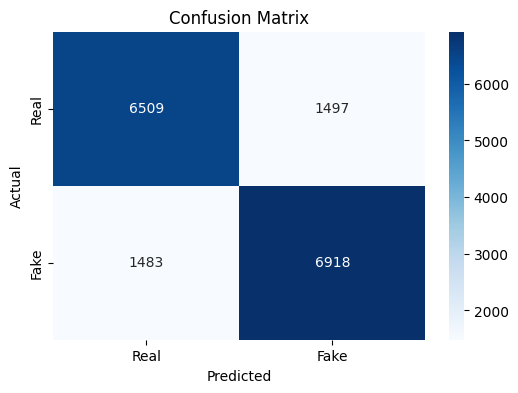

In [32]:


# Assuming y_test and y_pred are defined
cm = confusion_matrix(y_test, Y)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


<Axes: xlabel='label', ylabel='count'>

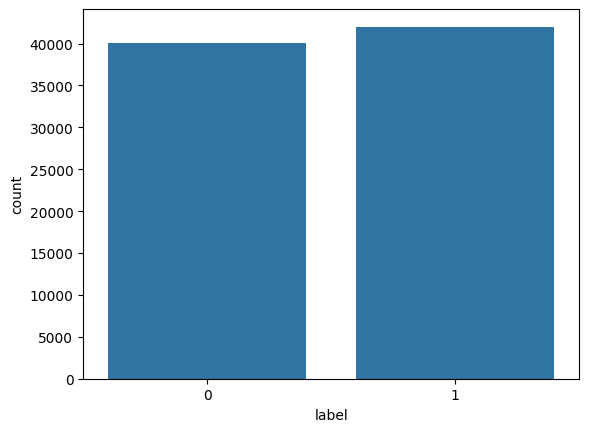

In [15]:
sns.countplot(data = df1, x= 'label')

In [33]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


NameError: name 'model' is not defined

In [68]:
import joblib

joblib.dump(model, "fake_news_pred_model2.pkl")
joblib.dump(vectorizer, "fake_news_vectorizer_model2.pkl")

['fake_news_vectorizer_model2.pkl']